# Phase 6 — Deployment / Suggested Application (CRISP-DM)

Conceptual deployment of the effectiveness classifier (Model 1) and side-effect topic model (Model 2) into a **review triage & insight** workflow.

Interactive prototype: `streamlit run app/streamlit_app.py` (3-class review scoring + side-effect topic matching with sample recommendations).

This is **not** a production medical device.


## Suggested Application: Drug Review Insight Console

**Users:** pharmacovigilance analysts, medical information teams, platform moderators  
**Job to be done:** Ingest new patient reviews, score perceived effectiveness, tag side-effect themes, and queue high-risk items for human review.

**Core screens (conceptual)**
1. **Inbox** — newest reviews with predicted effectiveness (3-class) and dominant side-effect topic
2. **Theme explorer** — LDA topic volumes over time
3. **Review detail** — raw text, cleaned tokens, top contributing TF-IDF terms, topic mixture
4. **Human review queue** — Low effectiveness and/or severe-topic hits requiring analyst sign-off

### Conceptual Architecture Diagram

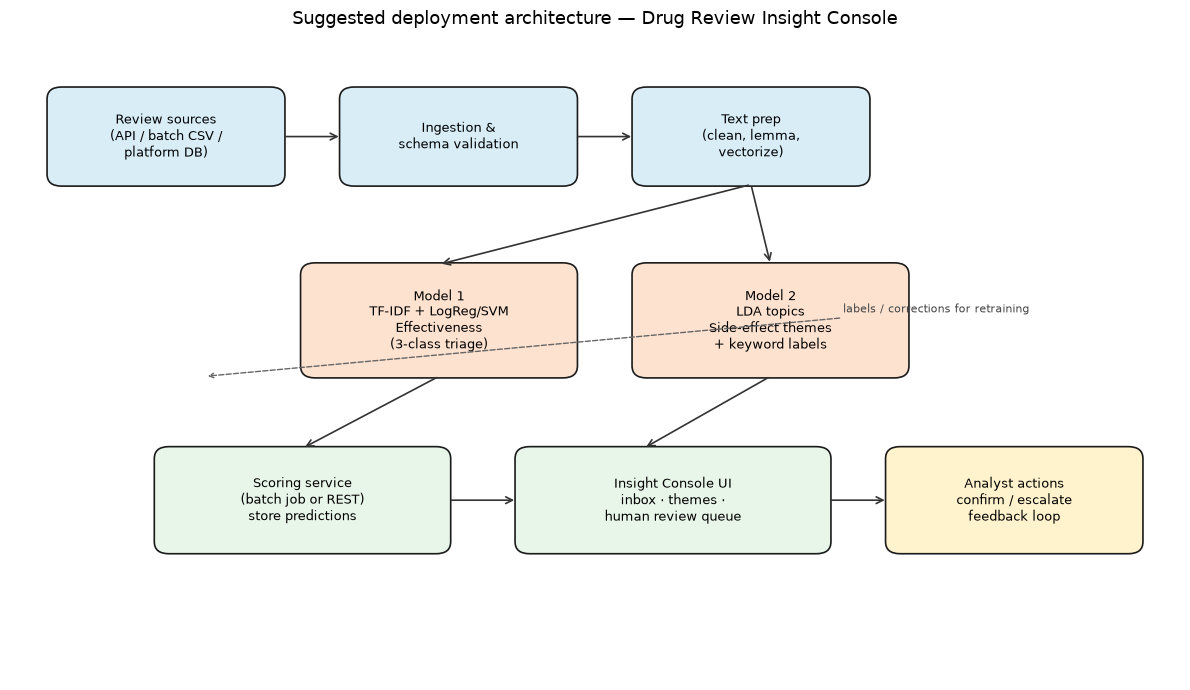

Saved visuals/deployment_architecture.png


In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.max_open_warning'] = 50
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from pathlib import Path

Path('../visuals').mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title('Suggested deployment architecture — Drug Review Insight Console', fontsize=13, pad=12)

def box(x, y, w, h, text, color):
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.02,rounding_size=0.15',
                           facecolor=color, edgecolor='#1b1b1b', linewidth=1.2)
    ax.add_patch(patch)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=9, wrap=True)

def arrow(x1, y1, x2, y2):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=12,
                                 linewidth=1.2, color='#333333'))

# Row 1: sources
box(0.4, 6.2, 2.4, 1.2, 'Review sources\n(API / batch CSV /\nplatform DB)', '#d9edf7')
box(3.4, 6.2, 2.4, 1.2, 'Ingestion &\nschema validation', '#d9edf7')
box(6.4, 6.2, 2.4, 1.2, 'Text prep\n(clean, lemma,\nvectorize)', '#d9edf7')

arrow(2.8, 6.8, 3.4, 6.8)
arrow(5.8, 6.8, 6.4, 6.8)

# Row 2: models
box(3.0, 3.8, 2.8, 1.4, 'Model 1\nTF-IDF + LogReg/SVM\nEffectiveness\n(3-class triage)', '#fde2d0')
box(6.4, 3.8, 2.8, 1.4, 'Model 2\nLDA topics\nSide-effect themes\n+ keyword labels', '#fde2d0')

arrow(7.6, 6.2, 4.4, 5.2)
arrow(7.6, 6.2, 7.8, 5.2)

# Row 3: serving + UI
box(1.5, 1.6, 3.0, 1.3, 'Scoring service\n(batch job or REST)\nstore predictions', '#e8f5e9')
box(5.2, 1.6, 3.2, 1.3, 'Insight Console UI\ninbox · themes ·\nhuman review queue', '#e8f5e9')
box(9.0, 1.6, 2.6, 1.3, 'Analyst actions\nconfirm / escalate\nfeedback loop', '#fff3cd')

arrow(4.4, 3.8, 3.0, 2.9)
arrow(7.8, 3.8, 6.5, 2.9)
arrow(4.5, 2.25, 5.2, 2.25)
arrow(8.4, 2.25, 9.0, 2.25)

# Feedback
ax.annotate('labels / corrections for retraining',
            xy=(2.0, 3.8), xytext=(9.5, 4.6),
            arrowprops=dict(arrowstyle='->', linestyle='--', color='#666'),
            fontsize=8, color='#444', ha='center')

plt.tight_layout()
plt.savefig('../visuals/deployment_architecture.png', dpi=150)
plt.show()
print('Saved visuals/deployment_architecture.png')

### End-to-End Workflow

1. **Ingest** new review (`benefitsReview`, `sideEffectsReview`, drug, condition).
2. **Preprocess** with the same cleaning function used in training; vectorize with persisted TF-IDF / Count vectorizers.
3. **Score Model 1** — predict 3-class effectiveness (primary triage) and optionally 5-class for detail.
4. **Score Model 2** — infer topic mixture; attach dominant topic label.
5. **Route** — if effectiveness=`Low` or topic in a high-concern set → human review queue; else → searchable archive.
6. **Monitor** — track prediction volume, class rates, topic drift; retrain on a schedule with analyst feedback.

### Scoring Sketch (pseudo-service)

In [2]:
import re
import pickle
import pandas as pd
from pathlib import Path

# Lightweight demo: load persisted Model 1 (3-class) if available and score a sample string.
# Full production would also load LDA + shared clean_text utilities as a package.

SAMPLE = "This medication finally reduced my pain and I could sleep through the night."

def clean_text_simple(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

artifacts = Path('../data/processed')
try:
    with open(artifacts / 'tfidf_vectorizer.pkl', 'rb') as f:
        vectorizer = pickle.load(f)
    with open(artifacts / 'model1_log_reg_3.pkl', 'rb') as f:
        clf = pickle.load(f)
    X = vectorizer.transform([clean_text_simple(SAMPLE)])
    pred = clf.predict(X)[0]
    if hasattr(clf, 'predict_proba'):
        proba = dict(zip(clf.classes_, clf.predict_proba(X)[0].round(3)))
    else:
        proba = {}
    print('Sample benefits text:', SAMPLE)
    print('Predicted effectiveness (3-class):', pred)
    print('Class probabilities:', proba)

    # Illustrative API payload
    payload = {
        'review_id': 'demo-001',
        'effectiveness_3class': pred,
        'effectiveness_proba': proba,
        'side_effect_topic': '(attach LDA dominant topic in full service)',
        'route': 'human_review' if pred == 'Low' else 'archive',
    }
    print('\nExample response payload:')
    for k, v in payload.items():
        print(f'  {k}: {v}')
except FileNotFoundError as e:
    print('Artifacts not found — run notebooks 02–04 first.', e)

Sample benefits text: This medication finally reduced my pain and I could sleep through the night.
Predicted effectiveness (3-class): Moderate
Class probabilities: {'High': np.float64(0.361), 'Low': np.float64(0.102), 'Moderate': np.float64(0.537)}

Example response payload:
  review_id: demo-001
  effectiveness_3class: Moderate
  effectiveness_proba: {'High': np.float64(0.361), 'Low': np.float64(0.102), 'Moderate': np.float64(0.537)}
  side_effect_topic: (attach LDA dominant topic in full service)
  route: archive


### Integration Options

| Mode | When to use |
|------|-------------|
| **Nightly batch** | Score exports from the review platform; write results to a warehouse table powering BI dashboards |
| **REST microservice** | On-submit scoring for live moderation queues |
| **Notebook / analytics** | Ad-hoc research — current repository pattern |

Human-in-the-loop is mandatory for High-concern side-effect topics and Low-effectiveness predictions before any outbound patient or clinician communication.

### Production Caveats

- **License:** UCI Druglib data is for non-commercial research; production use needs appropriately licensed corpora.
- **Not medical advice:** UI copy must state that outputs are automated research signals only.
- **Drift:** drug mix and language change over time — monitor topic coherence and class priors; retrain periodically.
- **Security & privacy:** treat free text as sensitive; restrict access; avoid logging full review bodies in insecure channels.
- **Explainability:** ship top contributing terms (LR coefficients × TF-IDF) beside each prediction for analyst trust.

### Interactive Prototype (Streamlit)

An interactive console is implemented in [`app/streamlit_app.py`](../app/streamlit_app.py):

1. **Effectiveness Classifier** — benefits review → 3-class prediction + hardcoded sample recommendation  
2. **Side-Effect Topic Matcher** — free-text symptoms → LDA topic matches + hardcoded per-topic suggestions  

```bash
pip install -r requirements.txt
# run notebooks 02–04 so data/processed/ models exist
streamlit run app/streamlit_app.py
```

Recommendations are demo/non-medical tips stored in `app/artifacts/recommendations.json`.


## Project Close

CRISP-DM phases completed as notebooks `00`–`06`:

1. Business Understanding — problem, stakeholders, ethics  
2. Data Understanding — EDA on Druglib reviews  
3. Text Data Preparation — clean, TF-IDF, DTM, 3-class mapping  
4. Modeling — Model 1 (LR/SVM, 3 vs 5 class) + Model 2 (LDA topics)  
5. Evaluation — comparative metrics and limitations  
6. Deployment — Insight Console architecture and scoring sketch